2017: GOS2017114.npy, station 300, oxygen unit = raw_as_mL/L
2018: GOS2018111.npy, station 415, oxygen unit = raw_as_mL/L
2019: GOS2019114.npy, station 385, oxygen unit = umol/kg_to_mL/L


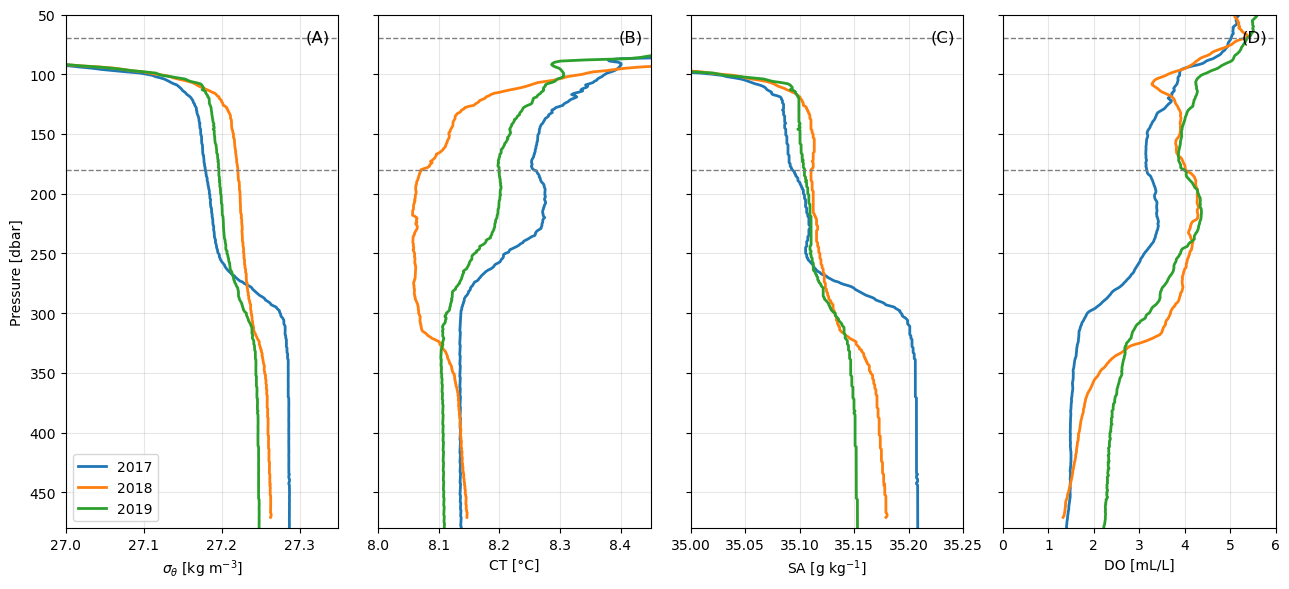

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gsw

# =========================
# 1. File paths and station settings
# =========================
data_dir = Path(r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy")

files = {
    "2017": ("GOS2017114.npy", 300),
    "2018": ("GOS2018111.npy", 415),
    "2019": ("GOS2019114.npy", 385),
}

# sill depths
sill_depths = [70, 180]

# =========================
# 2. Read one station profile and compute variables
# =========================
def load_station_profile(file_path, station_id):
    """
    Read one CTD profile from a .npy file and compute:
    P, sigma0, CT, SA, DO_mLL
    """

    D = np.load(file_path, allow_pickle=True).item()

    if station_id not in D:
        raise KeyError(
            f"Station {station_id} not found in {file_path.name}.\n"
            f"Available stations: {list(D.keys())}"
        )

    prof = D[station_id]

    P  = np.asarray(prof["P"], dtype=float)
    T  = np.asarray(prof["T"], dtype=float)   # in-situ temperature
    SP = np.asarray(prof["S"], dtype=float)   # practical salinity
    OX = np.asarray(prof["OX"], dtype=float)

    lon = float(prof["LON"])
    lat = float(prof["LAT"])

    # basic quality control
    good = np.isfinite(P) & np.isfinite(T) & np.isfinite(SP) & np.isfinite(OX)

    P  = P[good]
    T  = T[good]
    SP = SP[good]
    OX = OX[good]

    # sort by pressure (shallow → deep)
    idx = np.argsort(P)
    P  = P[idx]
    T  = T[idx]
    SP = SP[idx]
    OX = OX[idx]

    # TEOS-10 calculations
    SA = gsw.SA_from_SP(SP, P, lon, lat)
    CT = gsw.CT_from_t(SA, T, P)
    sigma0 = gsw.sigma0(SA, CT)

    rho = gsw.rho(SA, CT, P)      # kg/m3
    rho_kgL = rho / 1000.0        # kg/L

    # convert oxygen to mL/L
    # if values are small, assume already in mL/L
    # otherwise assume umol/kg and convert
    O_mean_raw = np.nanmean(OX)

    if O_mean_raw < 20:
        DO_mLL = OX
        unit_flag = "raw_as_mL/L"
    else:
        DO_mLL = OX * rho_kgL / 44.66
        unit_flag = "umol/kg_to_mL/L"

    return {
        "P": P,
        "sigma0": sigma0,
        "CT": CT,
        "SA": SA,
        "DO_mLL": DO_mLL,
        "unit_flag": unit_flag,
    }


# =========================
# 3. Read all profiles
# =========================
profiles = {}

for label, (fname, st) in files.items():
    file_path = data_dir / fname
    profiles[label] = load_station_profile(file_path, st)
    print(f"{label}: {fname}, station {st}, oxygen unit = {profiles[label]['unit_flag']}")


# =========================
# 4. Plot 4-panel figure
# =========================
fig, axes = plt.subplots(1, 4, figsize=(13, 6), sharey=True)

panel_info = [
    ("sigma0", r"$\sigma_\theta$ [kg m$^{-3}$]", (27.0, 27.35)),
    ("CT", "CT [°C]", (8, 8.45)),
    ("SA", r"SA [g kg$^{-1}$]", (35.0, 35.25)),
    ("DO_mLL", "DO [mL/L]", (0.0, 6.0))
]

for ax, (var, xlabel, xlim) in zip(axes, panel_info):

    for label, prof in profiles.items():
        ax.plot(
            prof[var],
            prof["P"],
            linewidth=2,
            label=label
        )

    # sill depth lines
    for sd in sill_depths:
        ax.axhline(
            sd,
            linestyle="--",
            linewidth=1,
            color="gray"
        )

    ax.set_xlabel(xlabel)
    ax.set_xlim(xlim)
    ax.grid(alpha=0.3)

    # pressure increases downward
    ax.invert_yaxis()

# shared y-axis range
axes[0].set_ylim(480, 50)
axes[0].set_ylabel("Pressure [dbar]")

# legend only on first subplot
axes[0].legend(loc="lower left")

# subplot labels
for ax, letter in zip(axes, ["(A)", "(B)", "(C)", "(D)"]):
    ax.text(
        0.97,
        0.97,
        letter,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12
    )

plt.tight_layout()
plt.show()